In [3]:
%matplotlib widget

!pip install ikpy matplotlib ipympl


[notice] A new release of pip is available: 23.0.1 -> 24.2
[notice] To update, run: pip install --upgrade pip


AppLayout(children=(VBox(children=(FloatSlider(value=30.0, description='X:', max=50.0, min=-50.0, step=1.0), F…

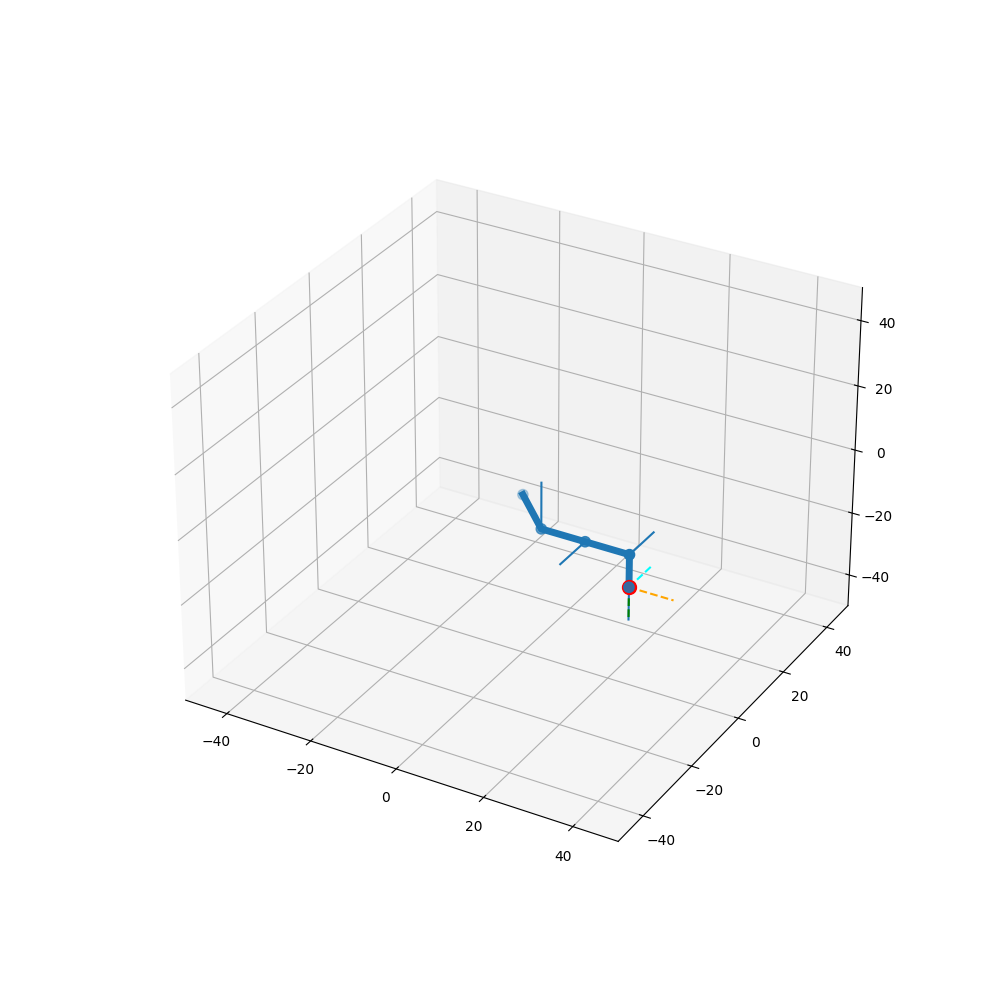

In [4]:
from ikpy.chain import Chain
from ikpy.link import OriginLink, URDFLink
import math
import ipywidgets as widgets
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from IPython.display import display

# Define the chain for the leg
leg1 = Chain(name='leg1', links=[
    OriginLink(),
    URDFLink(
        name="hip",
        #bounds=(0, math.radians(180)),
        origin_translation=[10, -10, 0],
        origin_orientation=[0, 0, math.radians(-90)],
        rotation=[0, 0, 1],
    ),
    URDFLink(
        name="knee",
        origin_translation=[10, 0, 0],
        origin_orientation=[0, math.radians(180), 0],
        rotation=[0, -1, 0],
    ),
    URDFLink(
        name="ankle",
        origin_translation=[0, 0, 10],
        origin_orientation=[0, math.radians(-90), 0],
        rotation=[0, 1, 0],
    ),
    URDFLink(
        name="pyatka",
        origin_translation=[10, 0, 0],
        origin_orientation=[0, 0, 0],
        rotation=[1, 0, 0],
    )
])

# Define the default position
default_position = [math.radians(0), math.radians(90), math.radians(90), math.radians(90), math.radians(0)]

# Create the figure and axes
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

# Plot the initial position of the leg
ik = leg1.inverse_kinematics([30, -10, -10])
leg1.plot(ik, ax, show=False)

# Create sliders for x, y, and z coordinates
x_slider = widgets.FloatSlider(min=-50, max=50, step=1, value=30, description='X:')
y_slider = widgets.FloatSlider(min=-50, max=50, step=1, value=-10, description='Y:')
z_slider = widgets.FloatSlider(min=-50, max=50, step=1, value=-10, description='Z:')

# Create read-only sliders for displaying the angles
hip_angle_slider = widgets.FloatSlider(min=0, max=180, step=0.1, value=0, description='Hip:')
knee_angle_slider = widgets.FloatSlider(min=0, max=180, step=0.1, value=0, description='Knee:')
ankle_angle_slider = widgets.FloatSlider(min=0, max=180, step=0.1, value=0, description='Ankle:')

# Make the angle sliders read-only
hip_angle_slider.disabled = True
knee_angle_slider.disabled = True
ankle_angle_slider.disabled = True

# Create a button widget
button = widgets.Button(description='Update', icon='check')

# Define the update function
def update_leg(change):
    x = x_slider.value
    y = y_slider.value
    z = z_slider.value
    ik = leg1.inverse_kinematics([x, y, z])
    ax.cla()  # Clear the axes
    leg1.plot(ik, ax, show=False)
    ax.scatter([x], [y], [z], color='r', s=100)  # Plot the target point
    ax.set_xlim([-50, 50])
    ax.set_ylim([-50, 50])
    ax.set_zlim([-50, 50])
    plt.draw()
    
    # Update the angle sliders
    hip_angle_slider.value = math.degrees(ik[1])
    knee_angle_slider.value = math.degrees(ik[2])
    ankle_angle_slider.value = math.degrees(ik[3])

# Attach the update function to the sliders and button
x_slider.observe(update_leg, names='value')
y_slider.observe(update_leg, names='value')
z_slider.observe(update_leg, names='value')
button.on_click(update_leg)

# Create an AppLayout with the figure, sliders, button, and angle sliders
app = widgets.AppLayout(
    center=fig.canvas,
    footer=widgets.VBox([x_slider, y_slider, z_slider, button, hip_angle_slider, knee_angle_slider, ankle_angle_slider]),
    pane_heights=[0, 6, 2]
)

# Display the layout
display(app)

# Initial call to update the plot
update_leg(None)
